<a href="https://colab.research.google.com/github/statftn/Deep-Learning-Theory-and-Practice/blob/main/chapter04_classification_and_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [ ]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 23.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.32.0 which is incompatible.


In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"
# Keras가 사용할 백엔드(계산 엔진)를 JAX로 지정
# Keras는 신경망 모델을 작성하기 쉽게 해주는 고수준 API이고, 실제 수치 계산은 백엔드(JAX, TensorFlow, PyTorch)에 맡겨 수행

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Classification and regression

### Classifying movie reviews: A binary classification example

#### The IMDb dataset

In [ ]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000   # utilizing 10000 most frequently used words (훈련 데이터에서 가장 자주 나타나는 단어 10000개만 사용)
)   # load imdb dataset
# 훈련 데이터에는 88585개의 고유한 단어가 포함
# 많은 단어가 하나에 샘플에만 등장하기 때문에 분류 작업에 의미있게 사용하기 위해 가장 자주 나타나는 단어 10000개만 사용

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_data[0]   # range: 0~9999 (because num_words=10000)

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [ ]:
train_labels[0]

np.int64(1)

In [ ]:
max([max(sequence) for sequence in train_data])   # maximum number of sequence (단어 10000개 제한 -> 인덱스는 9999까지)

9999

In [ ]:
min([min(sequence) for sequence in train_data])   # minimum number of sequence

1

In [ ]:
# convert the sequent integer to text (리뷰를 다시 텍스트로 디코딩)
word_index = imdb.get_word_index()   # get_word_index(): word to integer mapping (word -> integer number)
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])   # integer number -> word (리뷰 데이터는 숫자로 이루어짐)
decoded_review = " ".join(   # .join(): 단어 리스트를 공백으로 연결해서 하나의 문자열로 만들기
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]]   # .get(찾을 값, 없을 때 값)
)
# Keras의 IMDB 데이터에서는 대략적으로 다음과 같은 특수 토큰을 위해 인덱스가 예약되어 있다 (0 → padding, 1 → start, 2 → unknown)
# IMDB 데이터셋의 특수 토큰 인덱스와 실제 단어 인덱스의 차이 존재 -> 실제 단어 인덱스와 맞추기 위해 3을 빼서 word_index와 대응시키기
# 최종적으로 dedcoded_review에는 train_data[0]에 들어 있는 숫자 형태의 첫 번째 영화 리뷰를 영어 문장으로 복원한 문자열이 들어간다

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [ ]:
train_data[0]   # first review

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [ ]:
decoded_review   # decoded version of the first review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [ ]:
# the length of reviews are different (every review have different length)
print(len(train_data[0]))
print(len(train_data[1]))
print(len(train_data[2]))
# in machine learning method or deep learning method, we need fixed vector information

218
189
141


In [ ]:
decoded_review[:100]

"? this film was just brilliant casting location scenery story direction everyone's really suited the"

#### Preparing the data

In [ ]:
import numpy as np

def multi_hot_encode(sequences, num_classes):   # in machine learning method or deep learning method, we need fixed vector information -> in this case, we use multi-hot encoding
    results = np.zeros((len(sequences), num_classes))   # 리뷰 개수 x 10000 크기의 0으로 이루어진 배열
        results[i][sequence] = 1.0   # 리뷰에 있는 단어는 1.0, 나머지는 0 (개별 리뷰별로...) (i: 리뷰의 번호(행), sequence: 해당 리뷰에 포함된 단어 번호들 (열))
    return results
# IMDB 리뷰의 길이가 서로 다른 review(숫자 목록)들을 머신러닝 모델이 사용할 수 있는 10000(단어의 수) 크기의 0과 1로 이루어진 벡터(멀티-핫 벡터)로 변환
# 10개 단어의 multi-hot encoding 예시
# sequence = [2, 5, 8] -> [0 0 1 0 0 1 0 0 1 0]

# 훈련 데이터와 테스트 데이터를 벡터로 multi-hot encoding
x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

In [ ]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [ ]:
y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")
# 훈련 데이터, 테스트 데이터를 float32(32비트 실수형 데이터 타입)형태 벡터로 변환

#### Building your model

In [ ]:
import keras
from keras import layers

model = keras.Sequential(   # 모델 설정
    [
        layers.Dense(16, activation="relu"),   # Dense: 완전연결층
        layers.Dense(16, activation="relu"),   # relu: 중간층에서 복잡한 특징을 학습 -> 특징 추출
        layers.Dense(1, activation="sigmoid"),   # 임의의 값을 [0, 1] 사이로 압축 (< 0.5 → 부정적인 리뷰, ≥ 0.5 → 긍정적인 리뷰)
    ]
)

In [ ]:
model.compile(
    optimizer="adam",   # Adam: 각 가중치의 과거 gradient 정보를 이용하여 가중치별 업데이트 크기를 적응적으로 조절
    loss="binary_crossentropy",   # 이진분류(긍정 vs 부정) binary classification -> binary_crossentropy (원본 분포와 예측 분포 사이를 측정)
    metrics=["accuracy"],
)

#### Validating your approach

In [ ]:
x_val = x_train[:10000]   # x_train의 처음 10,000개를 validation 데이터로 사용 (0~9999번째)
partial_x_train = x_train[10000:]   # 실제 모델 학습에 사용할 데이터 (10000번째~)
y_val = y_train[:10000]
partial_y_train = y_train[10000:]
# x_train, y_train을 훈련 데이터와 검증 데이터로 분리
# split validation data by ourselves
# validation data -> 모델이 훈련 데이터에 과적합되는지 여부를 확인하는데 도움
# Training data → 모델을 실제로 학습, Validation data → 학습 중 모델 상태를 확인

In [ ]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),   # 검증 데이터를 이용해서 모델의 성능을 확인 (x_val, y_val은 가중치를 업데이트하는 학습에는 사용되지 않는다)
)
# 모델 학습
# 리뷰 데이터 -> 예측 -> 실제 정답과 비교 -> Loss 계산 -> Adam으로 가중치 수정
# epoch: 전체 학습 데이터를 한 번 전부 사용하는 것
# batch_size: 한 번에 모델에 넣어서 학습시키는 데이터 개수
# 한 epoch에 (학습 데이터 개수/512)번 학습
# history에는 20번의 학습 과정에서 loss, accuracy, val_loss, val_accuracy가 어떻게 변했는지가 저장

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7682 - loss: 0.5447 - val_accuracy: 0.8569 - val_loss: 0.3949
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9035 - loss: 0.2956 - val_accuracy: 0.8836 - val_loss: 0.3010
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9347 - loss: 0.2037 - val_accuracy: 0.8905 - val_loss: 0.2773
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9537 - loss: 0.1540 - val_accuracy: 0.8895 - val_loss: 0.2810
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9661 - loss: 0.1196 - val_accuracy: 0.8865 - val_loss: 0.2918
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9765 - loss: 0.0935 - val_accuracy: 0.8827 - val_loss: 0.3124
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9845 - loss: 0.0732 - val_accuracy: 0.8804 - val_loss: 0.3350
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9896 - loss: 0.0566 - val_accuracy: 0.8780 - v

In [ ]:
# history = model.fit(
#     x_train,
#     y_train,
#     epochs=20,
#     batch_size=512,
#     validation_split=0.2,   # training data에서 20%를 랜덤하게 분리하여 validation data로 사용
# )

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9849 - loss: 0.0482 - val_accuracy: 0.9886 - val_loss: 0.0331
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9956 - loss: 0.0174 - val_accuracy: 0.9858 - val_loss: 0.0440
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9991 - loss: 0.0084 - val_accuracy: 0.9864 - val_loss: 0.0444
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9999 - loss: 0.0049 - val_accuracy: 0.9852 - val_loss: 0.0474
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9999 - loss: 0.0041 - val_accuracy: 0.9846 - val_loss: 0.0488
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9999 - loss: 0.0038 - val_accuracy: 0.9840 - val_loss: 0.0504
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9999 - loss: 0.0035 - val_accuracy: 0.9836 - val_loss: 0.0523
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9999 - loss: 0.0034 - val_accuracy: 0.9840 - va

In [ ]:
history_dict = history.history
history_dict.keys()
# 학습 history에는 4개의 component 존재 (accuracy, loss, val_accuracy, val_loss)
# loss → 학습 데이터의 손실, accuracy → 학습 데이터의 정확도, val_loss → 검증 데이터의 손실, val_accuracy → 검증 데이터의 정확도

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

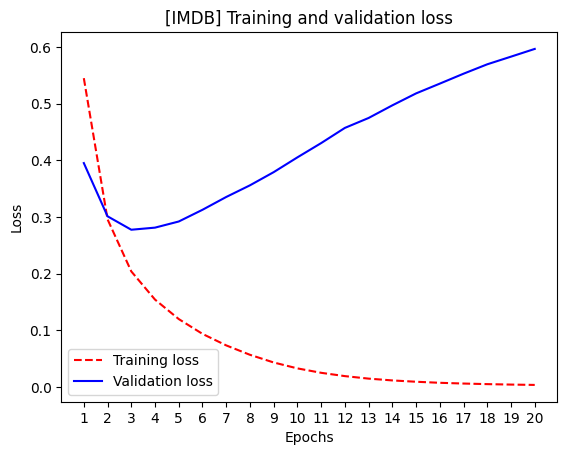

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]   # training loss
val_loss_values = history_dict["val_loss"]   # validation loss
epochs = range(1, len(loss_values) + 1)   # range: 마지막 숫자 포함X
plt.plot(epochs, loss_values, "r--", label="Training loss")   # x: epochs, y: training loss (붉은 점선)
plt.plot(epochs, val_loss_values, "b", label="Validation loss")   # x: epochs, y: validation loss (파란 실선)
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

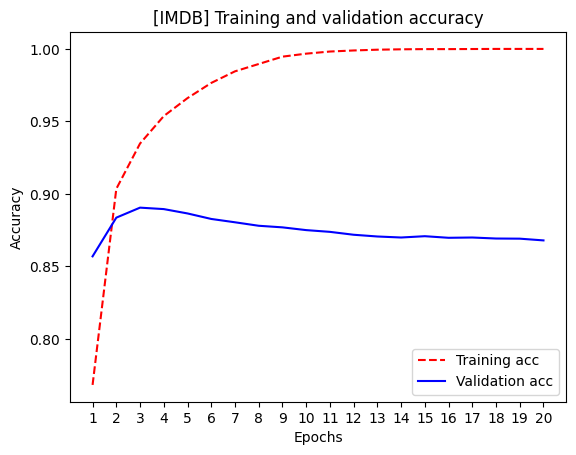

In [ ]:
plt.clf()   # 현재 Matplotlib의 그래프를 초기화(clear)
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")   # x: epochs, y: acc
plt.plot(epochs, val_acc, "b", label="Validation acc")   # x: epochs, y: val_acc
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(x_train, y_train, epochs=4, batch_size=512)   # because of the overfitting situation, we stop the training after epoch=4
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8143 - loss: 0.4505
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9164 - loss: 0.2283
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9417 - loss: 0.1685
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9552 - loss: 0.1330
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8775 - loss: 0.3237


In [ ]:
results   # validation accuracy 87% (for the validation data)
# [테스트 손실, 테스트 정확도]

[0.32373046875, 0.8774799704551697]

#### Using a trained model to generate predictions on new data

In [ ]:
model.predict(x_test)   # model.predict(): 새로운 데이터의 결과를 예측

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.1685277],
       [0.999946 ],
       [0.5834744],
       ...,
       [0.076836 ],
       [0.0386287],
       [0.6869714]], dtype=float32)

Some questions

In [ ]:
# Try fitting logistic regression, and check validation loss and accuracy
model = keras.Sequential(
    [
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7064 - loss: 0.6334 - val_accuracy: 0.7976 - val_loss: 0.5779
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8383 - loss: 0.5304 - val_accuracy: 0.8298 - val_loss: 0.5101
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8637 - loss: 0.4676 - val_accuracy: 0.8475 - val_loss: 0.4657
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8807 - loss: 0.4239 - val_accuracy: 0.8557 - val_loss: 0.4340
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8911 - loss: 0.3906 - val_accuracy: 0.8619 - val_loss: 0.4100
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8971 - loss: 0.3643 - val_accuracy: 0.8690 - val_loss: 0.3907
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9051 - loss: 0.3428 - val_accuracy: 0.8722 - val_loss: 0.3756
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9088 - loss: 0.3247 - val_accuracy: 0.8765 - v

In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

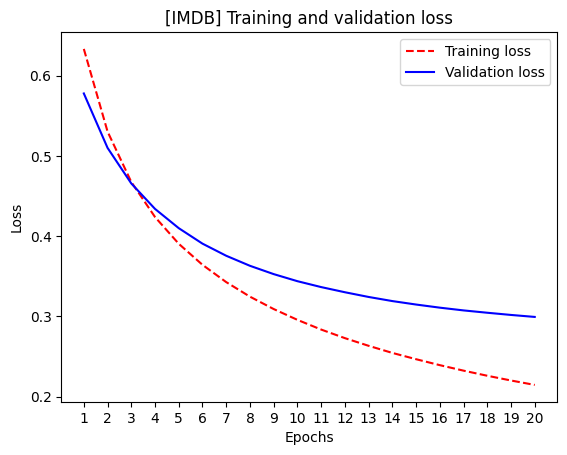

In [ ]:
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()
# no overfitting

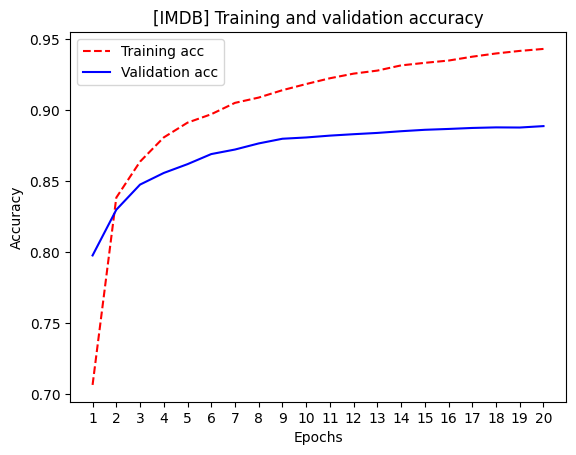

In [ ]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()
# since the model size is small, with the logistic regression, we are not detecting overfitting situation

In [ ]:
results = model.evaluate(x_test, y_test)
results
# validation accuracy is about 88%
# with only few number of layers with the simple logistic regression, for this problem, the result is similar

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8789 - loss: 0.3154


[0.3154257833957672, 0.878879964351654]

In [ ]:
# Try using one or three hidden layers, and check validation loss and accuracy
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [ ]:
# Try using layers with more hidden units or fewer hidden units
model = keras.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(4, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [ ]:
# Try using the mse loss function instead of binary_crossentropy
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["accuracy"],
)

In [ ]:
# Try using the tanh activation instead of relu
model = keras.Sequential(
    [
        layers.Dense(16, activation="tanh"),
        layers.Dense(16, activation="tanh"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

#### Further experiments

#### Wrapping up

### Classifying newswires: A multiclass classification example

#### The Reuters dataset

In [ ]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000   # 10000 most frequently used words
)
# Reuters 짧은 뉴스 기사와 토픽의 집합

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
len(train_data)

8982

In [ ]:
len(test_data)

2246

In [ ]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

In [ ]:
word_index = reuters.get_word_index()   # get_word_index(): Reuters 데이터셋의 단어와 정수 번호의 대응 관계 (단어 → 숫자)
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])   # 숫자 → 단어 ((value, key) → (key, value))
decoded_newswire = " ".join(   # join(): 단어 리스트를 공백으로 연결해서 하나의 문자열로 만들기
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]]   # get(찾을 값, 없을 때 값)
)
# 10번째 Reuters 뉴스가 숫자로 저장되어 있기 때문에, 숫자를 다시 단어로 변환해서 사람이 읽을 수 있는 뉴스 문장으로 복원

# Reuters 데이터셋에서는 실제 단어 번호 외에 몇 개의 특별한 토큰이 앞쪽 번호를 차지 (0 → padding(패딩), 1 → start(문서 시작), 2 → unknown(사전에 없음))
# Reuters 데이터셋의 특수 토큰 인덱스와 실제 단어 인덱스의 차이 존재 -> 실제 단어 인덱스와 맞추기 위해 3을 빼서 word_index와 대응시키기

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
decoded_newswire

'? period ended december 31 shr profit 11 cts vs loss 24 cts net profit 224 271 vs loss 511 349 revs 7 258 688 vs 7 200 349 reuter 3'

In [ ]:
train_labels[10]

np.int64(3)

#### Preparing the data

In [ ]:
# preprocessing the data to multi-hot encoding feature
# 입력 데이터(x_train, x_test) 멀티-핫 인코딩
x_train = multi_hot_encode(train_data, num_classes=10000)   # converts the data to fixed length vector
x_test = multi_hot_encode(test_data, num_classes=10000)   # after preprocessing, our input vector is 10000 length vector

In [ ]:
def one_hot_encode(labels, num_classes=46):   # Reuters 데이터셋에는 46개의 뉴스 카테고리가 있기 때문에 전체 클래스 기본값 46으로 설정
    results = np.zeros((len(labels), num_classes))   # labels 개수 (데이터 개수) x 10000 크기의 0으로 이루어진 배열
    for i, label in enumerate(labels):   # enumerate(): 리스트 같은 반복 가능한 객체를 순회하면서 인덱스와 값을 동시에 가져오는 함수
        results[i, label] = 1.0   # i번쩨 데이터 label이 가리키는 위치만 1로 만들고 나머지는 0으로 구성된 벡터 만들기
    return results

y_train = one_hot_encode(train_labels)   # y_train의 형태 (훈련 데이터 개수, 46)
y_test = one_hot_encode(test_labels)
# 정답 레이블을 one-hot encoding
# Reuters 데이터는 46개 클래스로 구성 -> 각 데이터가 길이 46짜리 벡터

In [ ]:
y_train[:5]

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 

In [ ]:
from keras.utils import to_categorical

y_train = to_categorical(train_labels)   # to_categorical: one-hot encoding
y_test = to_categorical(test_labels)

In [ ]:
y_train[:5]

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 

#### Building your model

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),   # two dense layers with 64 hidden dimension
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),   # softmax: multi-class classification (number of classes 46) 마지막 출력값들을 각 클래스일 확률값으로 변환 (모든 확률 더하면 1)
    ]
)

In [ ]:
top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(
    k=3, name="top_3_accuracy"   # 상위 3개까지 정답으로 인정해서 평가
)
# TopKCategoricalAccuracy(k=3):	상위 3개 예측 안에 정답이 있는지 측정
# 모델의 예측 결과에서 확률이 높은 상위 3개 카테고리 안에 실제 정답이 포함되어 있는지 확인하는 지표

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # y: one-hot encoded feature -> categorical_crossentropy
    metrics=["accuracy", top_3_accuracy],   # "accuracy" 가장 높은 확률의 예측이 정답인지 측정, top_3_accuracy: 상위 3개 예측 안에 정답이 있는지 측정
)

#### Validating your approach

In [ ]:
x_val = x_train[:1000]   # x_train의 처음 1000개를 validation 데이터로 사용 (0~9999번째)
partial_x_train = x_train[1000:]   # 실제 모델 학습에 사용할 데이터 (1000번째~)
y_val = y_train[:1000]
partial_y_train = y_train[1000:]
# split validation data by ourselves (x_train, y_train을 훈련 데이터와 검증 데이터로 분리)
# validation data -> 모델이 훈련 데이터에 과적합되는지 여부를 확인하는데 도움
# Training data → 모델을 실제로 학습, Validation data → 학습 중 모델 상태를 확인

In [ ]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - accuracy: 0.3994 - loss: 3.3916 - top_3_accuracy: 0.5615 - val_accuracy: 0.5910 - val_loss: 2.7039 - val_top_3_accuracy: 0.7190
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6320 - loss: 2.0868 - top_3_accuracy: 0.7404 - val_accuracy: 0.6460 - val_loss: 1.6838 - val_top_3_accuracy: 0.7670
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7136 - loss: 1.3388 - top_3_accuracy: 0.8126 - val_accuracy: 0.7090 - val_loss: 1.2967 - val_top_3_accuracy: 0.8160
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7798 - loss: 1.0060 - top_3_accuracy: 0.8651 - val_accuracy: 0.7500 - val_loss: 1.1399 - val_top_3_accuracy: 0.8370
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8341 - loss: 0.7818 - top_3_accuracy: 0.9107 - val_accuracy: 0.7780 - val_loss: 1.0443 - val_top_3_accuracy: 0.8760
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8727 - loss: 0.6061 - top_3_a

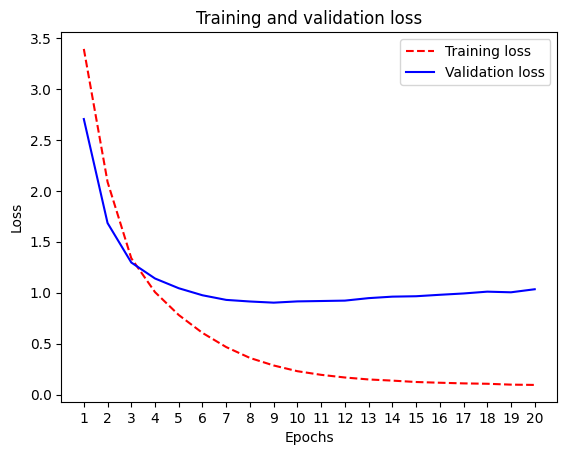

In [ ]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)   # range: 마지막 숫자 포함X
plt.plot(epochs, loss, "r--", label="Training loss")   # "r--": 빨강 점선
plt.plot(epochs, val_loss, "b", label="Validation loss")   # "b": 파랑 실선
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

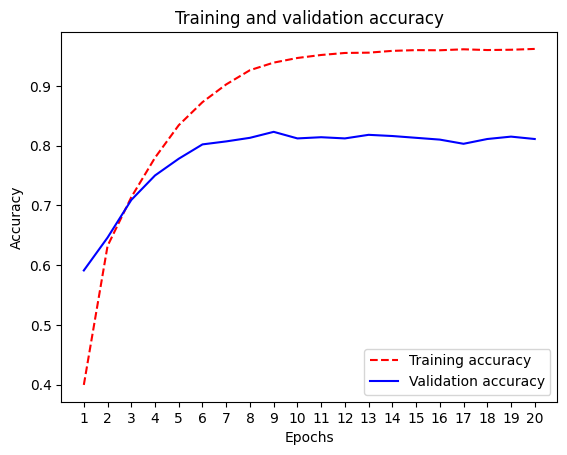

In [ ]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

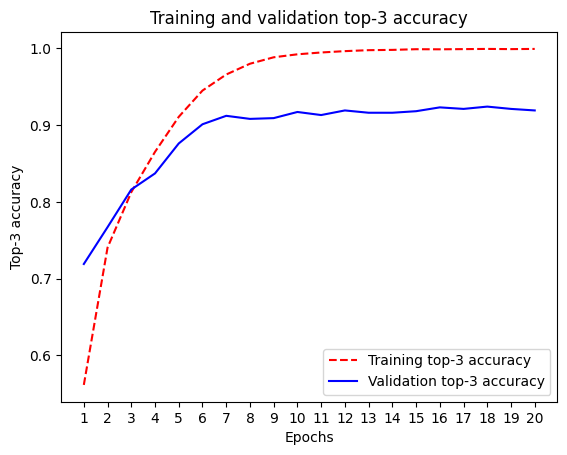

In [ ]:
plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.show()

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    x_train,
    y_train,
    epochs=9,   # after epoch=9, overfitting situation happens
    batch_size=512,
)
results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.4644 - loss: 3.1284
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6087 - loss: 1.8317
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7130 - loss: 1.3032
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7766 - loss: 1.0055
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8327 - loss: 0.7843
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8737 - loss: 0.6054
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9050 - loss: 0.4646
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9248 - loss: 0.3618
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9388 - loss: 0.2862
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8001 - loss: 0.9255


In [ ]:
results   # accuracy: about 80%

[0.9254732131958008, 0.8000890612602234]

In [ ]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels == test_labels_copy)
hits_array.mean()
# randomly shuffled test data -> how much accuracy can we get with random guessing: about 20%

np.float64(0.19367764915405164)

#### Generating predictions on new data

In [ ]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
predictions   # 46개 클래스에 대한 확률

array([[2.1015345e-05, 5.7966547e-04, 1.2376637e-06, ..., 7.1258939e-05,
        1.7791255e-05, 6.4374785e-06],
       [3.6445046e-03, 3.7019598e-01, 9.1329793e-04, ..., 2.7143050e-04,
        8.3312028e-05, 9.8200391e-05],
       [2.9458983e-03, 6.9348419e-01, 7.5517003e-03, ..., 2.6275066e-03,
        1.0007590e-03, 1.1019944e-03],
       ...,
       [1.9049105e-05, 1.6769585e-04, 2.7273848e-06, ..., 6.9836198e-05,
        2.1940321e-05, 2.0609254e-05],
       [9.8705792e-04, 8.1329867e-02, 3.7629300e-04, ..., 1.9005846e-03,
        2.5922267e-04, 7.5357099e-04],
       [8.3465886e-04, 2.4172632e-01, 2.4606155e-02, ..., 3.4990904e-03,
        6.2805397e-04, 1.8756415e-03]], dtype=float32)

In [ ]:
predictions[0].shape

(46,)

In [ ]:
np.sum(predictions[0])   # 다중분류(softmax) -> 각 클래스일 확률의 합은 1

np.float32(0.9999999)

In [ ]:
np.argmax(predictions[0])   # 첫번째 테스트 데이터는 3일 확률이 가장 높다

np.int64(3)

In [ ]:
y_test[0]   # 첫번째 테스트 데이터 레이블 3 (실제 값 확인)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
predictions[0]   # 첫번째 테스트 데이터는 3일 확률이 가장 높다

array([2.1015345e-05, 5.7966547e-04, 1.2376637e-06, 9.1660666e-01,
       7.0584536e-02, 2.8107030e-05, 3.5027181e-06, 6.7674817e-05,
       6.5509169e-03, 3.9822618e-05, 3.8750393e-05, 2.7545114e-04,
       1.3908098e-05, 7.7073136e-04, 6.8775721e-06, 2.7147187e-05,
       9.6055144e-04, 4.9722814e-05, 5.0401417e-05, 3.9376016e-04,
       6.3244620e-04, 5.4448092e-04, 2.5372492e-05, 2.4405641e-04,
       3.5367000e-06, 1.2522600e-04, 1.7774032e-06, 4.0707309e-05,
       3.5154397e-05, 3.0668030e-05, 2.6790067e-04, 2.6714499e-04,
       9.0938061e-05, 8.3844843e-06, 3.3336834e-04, 1.2650998e-05,
       2.4406865e-05, 4.0620558e-05, 2.5150037e-05, 4.9594139e-05,
       4.8419356e-06, 1.7249451e-05, 8.4011726e-06, 7.1258939e-05,
       1.7791255e-05, 6.4374785e-06], dtype=float32)

#### A different way to handle the labels and the loss

In [ ]:
y_train = train_labels
y_test = test_labels

In [ ]:
y_test[:10]

array([ 3, 10,  1,  4,  4,  3,  3,  3,  3,  3])

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",   # y: integer value variables -> sparse_categorical_crossentropy
    metrics=["accuracy"],
)
# sparse_categorical_crossentropy: automatically convert integer values to one-hot encoded feature (정수 레이블 사용하는 경우)
# categorical_crossentropy: 범주형 인코딩된 레이블 (one-hot encoded) 사용하는 경우

#### The importance of having sufficiently large intermediate layers

In [ ]:
y_train[:5]

array([3, 4, 3, 4, 4])

In [ ]:
partial_y_train[:5]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="relu"),   # too small or too large dimension in hidden layer -> worse performance (정보의 병목)
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # partial_y_train: one-hot encoded -> categorical_crossentropy (not sparse_categorical_crossentropy)
    metrics=["accuracy"],
)
model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val),
)
# 마지막 출력(다중분류) 46차원 -> 중간층의 유닛이 46개보다 많이 적어서는 안 된다
# 많은 정보(클래스 46개)를 중간층의 저차원 표현 공간으로 압축하려고 하며 정확도 손실 발생
# 46차원보다 훨씬 작은 4차원 중간층을 두면 정보 병목 -> 검증 정확도(val_accuracy)의 최고 값이 약 71%로 8% 정도 감소

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.0921 - loss: 3.4308 - val_accuracy: 0.4100 - val_loss: 2.8482
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4677 - loss: 2.1409 - val_accuracy: 0.5150 - val_loss: 1.7783
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6924 - loss: 1.3399 - val_accuracy: 0.6980 - val_loss: 1.3098
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7353 - loss: 1.0639 - val_accuracy: 0.7100 - val_loss: 1.2671
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7478 - loss: 0.9538 - val_accuracy: 0.7100 - val_loss: 1.2570
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7557 - loss: 0.8718 - val_accuracy: 0.7030 - val_loss: 1.2609
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7606 - loss: 0.8018 - val_accuracy: 0.7060 - val_loss: 1.2736
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7845 - loss: 0.7416 - val_accuracy: 0.7050 - val_loss

Some questions

In [ ]:
# Solve the same problem without using one-hot encoding y variable
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="relu"),   # too small or too large dimension in hidden layer -> worse performance
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",   # y_train: integer values -> sparse_categorical_crossentropy
    metrics=["accuracy"],
)
model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

In [ ]:
# Try using larger or smaller layers

In [ ]:
# Try using a single hidden layer, or three hidden layers

#### Further experiments

#### Wrapping up

### Predicting house prices: A regression example

#### The California Housing Price dataset

In [ ]:
from keras.datasets import california_housing

(train_data, train_targets), (test_data, test_targets) = (
    california_housing.load_data(version="small")
)
# The California Housing Price dataset (small version (600 districts))
# median price of homes in different areas of California, based on data from the 1990 census

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [ ]:
train_data.shape   # 480 training samples, with 8 numerical features

(480, 8)

In [ ]:
test_data.shape   # 120 test samples, with 8 numerical features

(120, 8)

In [ ]:
train_targets   # The prices are between $60,000 and $500,000

array([228400., 132900.,  60000.,  95200., 107000., 122500., 132000.,
       290100., 257800., 390100., 220800., 284900.,  97500., 415300.,
        84200., 185600., 216700., 233100., 127000., 182300.,  92300.,
        90700., 102100., 112500., 350700., 156500., 220700., 147400.,
       216700., 275000., 198200., 119100., 289500., 152500., 125000.,
       104500.,  93800.,  89300., 452600., 128600., 311500.,  90000.,
       218200., 131300.,  67500., 139400., 500001., 182600., 111300.,
       112500., 134700.,  71300., 207400., 331400., 107900.,  87500.,
       342200.,  87100., 314700., 368600., 211600., 338900., 366100.,
       164300.,  91700., 261400., 218500., 155400., 273700.,  81800.,
       138800.,  99700., 156300., 140600., 152700., 108900., 351200.,
       126000., 137500., 196900., 240000., 172800., 254200.,  97500.,
       182700., 162500.,  86100., 226700., 412500., 165900., 327100.,
       162500., 188800., 183800.,  90600., 372000., 275000., 151800.,
       125000., 1291

#### Preparing the data

In [ ]:
mean = train_data.mean(axis=0)   # axis=0: column-wise calculation
std = train_data.std(axis=0)   # 각 특성(feature)별 평균, 표준편차
x_train = (train_data - mean) / std   # x values -> normalize
x_test = (test_data - mean) / std   #  normalizing: 신경망에서 각 특성(feature)의 값 범위를 비슷하게 만들어 학습이 잘 되도록 하는 목적

In [ ]:
# Our normalized inputs have their value in a small range close to 0, and our model's weights are initialized with small random values.
# This means that our model's prediction will also be small values when we start training. -> we should also scale the targets.
y_train = train_targets / 100000   # y values -> scaling (because data values are too big (targets are in the range 60,000–500,000))
y_test = test_targets / 100000   # smallest target becomes 0.6, and the largest becomes 5
# We can then convert the model's predictions back to dollar values by multiplying them by 100,000 accordingly

#### Building your model

In [ ]:
def get_model():   # define function (함수 정의)
    model = keras.Sequential(   # 신경망 구조 정의
        [
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(1),   # for the regression problem, model ends with a single unit and no activation
        ]
    )
    model.compile(   # 학습 방법 설정
        optimizer="adam",   # adam: 가중치를 효율적으로 업데이트해 주는 알고리즘
        loss="mean_squared_error",   # loss: 학습에 직접 사용하는 기준
        metrics=["mean_absolute_error"],   # metrics: 성능을 확인하기 위해 함께 표시하는 값
    )
    return model

#### Validating your approach using K-fold validation

In [ ]:
k = 4   # 4개의 fold(부분)로 나누기 (일반적으로 K = 4 or 5)
num_val_samples = len(x_train) // k  # 검증 데이터에 들어갈 샘플 개수를 계산 (//: 몫만 구하기)
num_epochs = 50   # 모델을 50번 반복 학습
all_scores = []   # 각 fold에서 나온 MAE 결과를 저장할 빈 리스트
for i in range(k):
    print(f"Processing fold #{i + 1}")   # k=4 -> 총 4번 반복
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]   # 검증 데이터 준비: k번째 분할
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(   # np.concatenate()는 앞쪽 학습 데이터와 뒤쪽 학습 데이터를 다시 이어 붙이는 역할
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )   # 현재 검증에 사용하고 있는 부분을 제외한 나머지를 학습 데이터로 만들기
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()   # fold마다 새로운 모델을 만들기 (이전 fold에서 학습한 가중치가 다음 fold에 영향을 주면 안 되기 때문)
    model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,   # 학습 과정의 출력 메세지 표시하지X
    )
    scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)   # evaluate after all the training
    val_loss, val_mae = scores
    # 앞에서 get_model()을 정의할 때 model.compile()에서 loss="mean_squared_error", metrics=["mean_absolute_error"]로 설정
    # evaluate() 결과 [MSE, MAE]. 따라서 val_loss → MSE, val_mae → MAE
    all_scores.append(val_mae)   # 현재 fold의 MAE를 all_scores에 저장 (4번 반복하고 나면 all_scores에는 4개의 MAE값이 존재)

# 데이터양이 적을 경우 검증 세트와 훈련 세트로 어떤 데이터 포인트가 선택되었는지에 따라 검증 점수가 크게 달라진다
# 데이터양이 적을 때는 K-fold validation이 신뢰할 수 있는 모델 평가를 도와준다
# K-fold 교차 검증(K-fold cross-validation)을 이용해서 신경망 모델의 성능을 평가
# 훈련 데이터를 4개로 나누고, 각각 한 번씩 검증 데이터로 사용하면서 모델을 총 4번 학습

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [ ]:
[round(value, 3) for value in all_scores]

[0.314, 0.307, 0.24, 0.309]

In [ ]:
round(np.mean(all_scores), 3)   # entire point of K-fold cross-validation
# 실제 주택 가격에서 평균적으로 $29,600 정도 차이 존재 (prices range from $60,000 to $500,000)

np.float64(0.292)

In [ ]:
# to detect the overfitting problem, we should keep track a records (epochs = 200)
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []   # saving all mae histories inside this dictionary
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)
# 4 components results are saved inside of all_mae_histories

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [ ]:
all_mae_histories
# 200(=epochs) MAE values

[[1.120665192604065,
  0.7207441926002502,
  0.6047983765602112,
  0.5439704656600952,
  0.5212423801422119,
  0.49853548407554626,
  0.4848959743976593,
  0.46695125102996826,
  0.4556840658187866,
  0.4508049786090851,
  0.43489596247673035,
  0.42452698945999146,
  0.41609328985214233,
  0.4234934449195862,
  0.39998534321784973,
  0.3901272118091583,
  0.3914293944835663,
  0.3623494505882263,
  0.3576100468635559,
  0.3815545439720154,
  0.34844622015953064,
  0.37015828490257263,
  0.3574983477592468,
  0.32777735590934753,
  0.3314261734485626,
  0.3163139224052429,
  0.34414246678352356,
  0.31601211428642273,
  0.30675971508026123,
  0.3251247704029083,
  0.32171106338500977,
  0.3095858693122864,
  0.3075657784938812,
  0.3000014126300812,
  0.3068002164363861,
  0.314334899187088,
  0.33815422654151917,
  0.3143828511238098,
  0.30420881509780884,
  0.29887625575065613,
  0.30872026085853577,
  0.30225613713264465,
  0.30593767762184143,
  0.30051177740097046,
  0.3101958632

In [ ]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]
# for all number of epochs, calculate the mean of all folds values

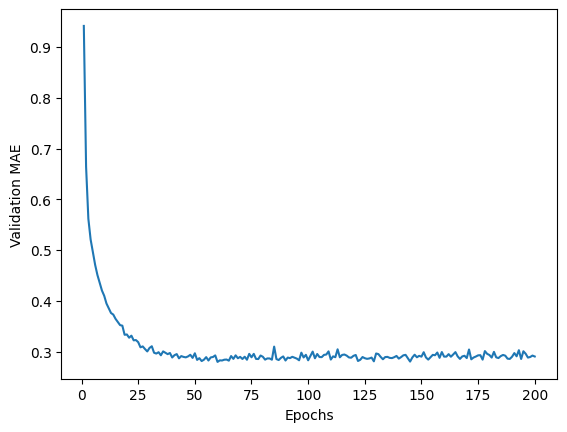

In [ ]:
epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

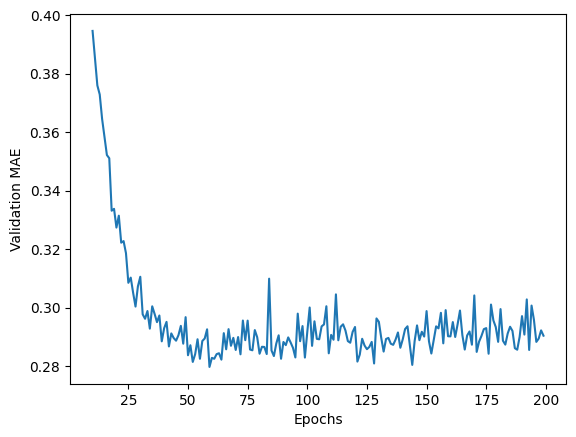

In [ ]:
truncated_mae_history = average_mae_history[10:]   # skip the first 10 epochs
epochs = range(10, len(truncated_mae_history) + 10)
plt.plot(epochs, truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()
# validation MAE stops improving significantly after 120–140 epochs
# Past that point, it starts overfitting

In [ ]:
model = get_model()   # 교차 검증에서 사용했던 모델과 별개의 새로운 모델
model.fit(x_train, y_train, epochs=130, batch_size=16, verbose=0)   # x_train, y_train 전체를 학습, verbose=0: 학습 과정의 출력 내용을 화면에 표시하지 않기
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    x_test, y_test
)   # 테스트 데이터로 평가

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.2980 - mean_absolute_error: 0.3183


In [ ]:
round(test_mean_absolute_error, 3)   # mae score for the test dataset
# 아직 실제 주택 가격과 예측 결과가 $31,000 정도 차이 존재

0.318

#### Generating predictions on new data

In [ ]:
predictions = model.predict(x_test)
predictions[0]
# 테스트 세트에 있는 첫 번째 주택의 가격은 약 $240,000로 예상

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([2.378526], dtype=float32)

Some questions

In [ ]:
# Try varying the number of layers in the model

In [ ]:
# Try varying the number of units per layer

In [ ]:
# Try to visualize results (validation accuracy or validation loss) for comparison

#### Wrapping up